<a href="https://colab.research.google.com/github/CHIRANJEEVBHATT/Machine-learning-/blob/main/AutoPrice_Compass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoPrice Compass — Data Analysis + Classification
**PBL-I Project Review** · Dataset: *Used Car Prices (India)* — Kaggle `sujay1844/used-car-prices` (`train.csv`)

**Problem.** Used-car value depends on age, mileage, fuel type, transmission, ownership and engine attributes. Static rule-based pricing ignores these interactions, so this notebook builds a data-driven pipeline to estimate prices transparently.

**This notebook covers:** Part 2 – Exploratory Data Analysis & Insights, and Part 3 – Classification Implementation (Logistic Regression and Support Vector Machine with RBF kernel).


In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# Consistent palette used across notebooks and the presentation
NAVY, TEAL, AMBER, CORAL, SLATE = '#1F3A5F', '#2A9D8F', '#E9A23B', '#E76F51', '#6B7A8F'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('figures', exist_ok=True)
RANDOM_STATE = 42

DATA_PATH = 'train.csv' if os.path.exists('train.csv') else '/content/train.csv'
raw = pd.read_csv(DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (5847, 14)


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


## 1. Data understanding

In [2]:
raw.info()
print()
print('Duplicate rows (ignoring index column):', raw.duplicated(subset=raw.columns[1:]).sum())
miss = raw.isna().sum().to_frame('missing'); miss['pct'] = (miss.missing / len(raw) * 100).round(1)
miss[miss.missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   object 
 2   Location           5847 non-null   object 
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   object 
 6   Transmission       5847 non-null   object 
 7   Owner_Type         5847 non-null   object 
 8   Mileage            5845 non-null   object 
 9   Engine             5811 non-null   object 
 10  Power              5811 non-null   object 
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    object 
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 639.6+ KB

Duplicate rows (ignoring index column): 0


,missing,pct
Mileage,2,0.0
Engine,36,0.6
Power,36,0.6
Seats,38,0.6
New_Price,5032,86.1


**Observations.** `Mileage`, `Engine`, `Power` are stored as text with units (kmpl, CC, bhp); `New_Price` is ~86 % missing so it is dropped; `Seats`, `Engine`, `Power` have a few dozen gaps (imputed later inside the model pipeline to avoid leakage).

## 2. Data cleaning & feature engineering

In [3]:
df = raw.drop(columns=['Unnamed: 0', 'New_Price']).copy()

# Numeric extraction from text columns
df['Mileage'] = pd.to_numeric(df['Mileage'].str.extract(r'([\d.]+)')[0], errors='coerce')
df['Engine']  = pd.to_numeric(df['Engine'].str.extract(r'([\d.]+)')[0], errors='coerce')
df['Power']   = pd.to_numeric(df['Power'].str.extract(r'([\d.]+)')[0], errors='coerce')
df.loc[df['Mileage'] == 0, 'Mileage'] = np.nan          # 0 kmpl is a data-entry gap

# Brand from the first word of Name; fix split/duplicate spellings
df['Brand'] = df['Name'].str.split().str[0].replace({'Land': 'Land Rover', 'ISUZU': 'Isuzu'})
# Car age relative to the newest model year in the data
REF_YEAR = df['Year'].max()
df['Age'] = REF_YEAR - df['Year']

# Remove physically implausible odometer readings (> 500,000 km)
before = len(df)
df = df[df['Kilometers_Driven'] <= 500_000].reset_index(drop=True)
print(f'Removed {before-len(df)} extreme-odometer rows -> {len(df)} rows remain')
df = df.drop(columns=['Name', 'Year'])
df.head()

Removed 4 extreme-odometer rows -> 5843 rows remain


,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Age
0,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,4
1,Chennai,46000,Petrol,Manual,First,13.00,1199.0,88.70,5.0,4.50,Honda,8
2,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,7
3,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,6
4,Jaipur,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50,Nissan,6


## 3. Exploratory Data Analysis

### 3.1 Summary statistics

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Kilometers_Driven,5843.0,56975.71,34903.75,171.00,33437.50,52516.00,72457.50,480000.0
Mileage,5801.0,18.28,4.10,6.40,15.29,18.20,21.10,28.4
Engine,5807.0,1631.34,601.87,72.00,1198.00,1497.00,1991.00,5998.0
Power,5807.0,113.78,53.88,34.20,78.00,98.60,138.56,560.0
Seats,5805.0,5.29,0.81,2.00,5.00,5.00,5.00,10.0
Price,5843.0,9.65,11.26,0.44,3.55,5.75,10.25,160.0
Age,5843.0,5.55,3.20,0.00,3.00,5.00,7.00,21.0


### 3.2 Target variable — Price (₹ Lakh)

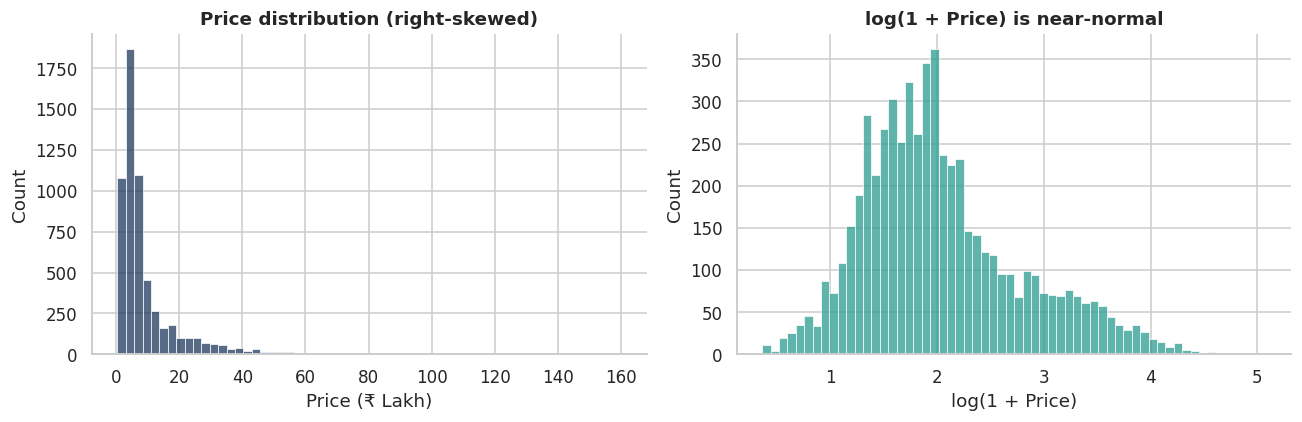

Skewness  raw: 3.31 | log: 0.75
Median price: 5.75 Lakh | Mean: 9.65 Lakh


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price'], bins=60, color=NAVY, ax=ax[0]); ax[0].set_title('Price distribution (right-skewed)'); ax[0].set_xlabel('Price (₹ Lakh)')
sns.histplot(np.log1p(df['Price']), bins=60, color=TEAL, ax=ax[1]); ax[1].set_title('log(1 + Price) is near-normal'); ax[1].set_xlabel('log(1 + Price)')
plt.tight_layout(); plt.savefig('figures/eda_price_dist.png', dpi=160, bbox_inches='tight'); plt.show()
print('Skewness  raw: %.2f | log: %.2f' % (df['Price'].skew(), np.log1p(df['Price']).skew()))
print('Median price: %.2f Lakh | Mean: %.2f Lakh' % (df['Price'].median(), df['Price'].mean()))

**Insight.** Price is strongly right-skewed (a few luxury cars cost 50–160 Lakh). A log transform removes most of the skew, which suits linear models whose residuals are assumed roughly Gaussian.

### 3.3 Age and usage vs price

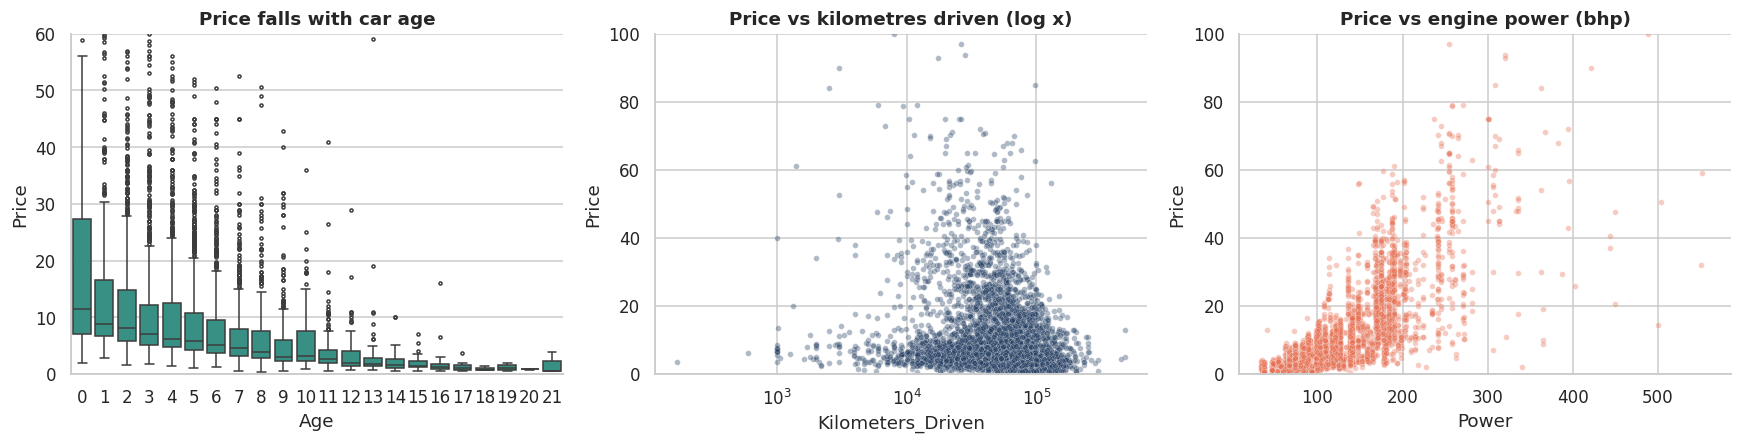

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.boxplot(data=df, x='Age', y='Price', color=TEAL, fliersize=2, ax=ax[0]); ax[0].set_title('Price falls with car age'); ax[0].set_ylim(0, 60)
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', alpha=.35, s=14, color=NAVY, ax=ax[1]); ax[1].set_xscale('log'); ax[1].set_title('Price vs kilometres driven (log x)'); ax[1].set_ylim(0, 100)
sns.scatterplot(data=df, x='Power', y='Price', alpha=.35, s=14, color=CORAL, ax=ax[2]); ax[2].set_title('Price vs engine power (bhp)'); ax[2].set_ylim(0, 100)
plt.tight_layout(); plt.savefig('figures/eda_age_km_power.png', dpi=160, bbox_inches='tight'); plt.show()

**Insight.** Median price drops steadily with age; very high-mileage cars cluster at low prices; power shows a clear positive relationship with price (premium/performance cars).

### 3.4 Categorical drivers

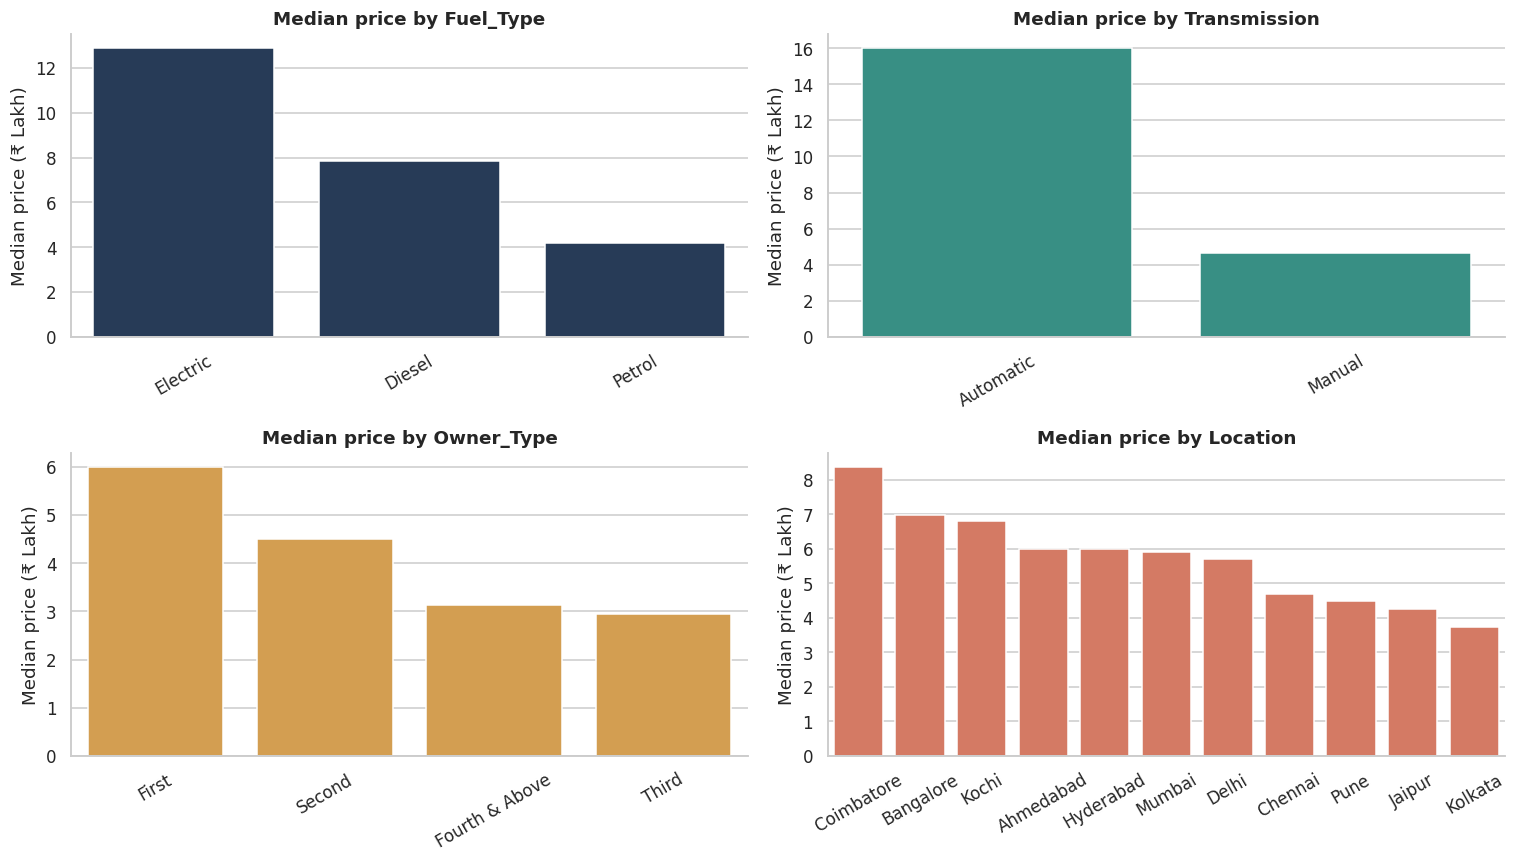

{'Automatic': 16.0, 'Manual': 4.65}


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for a, col, c in zip(ax.ravel(), ['Fuel_Type', 'Transmission', 'Owner_Type', 'Location'], [NAVY, TEAL, AMBER, CORAL]):
    order = df.groupby(col)['Price'].median().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='Price', order=order, estimator=np.median, errorbar=None, color=c, ax=a)
    a.set_title(f'Median price by {col}'); a.set_ylabel('Median price (₹ Lakh)'); a.set_xlabel('')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('figures/eda_categorical.png', dpi=160, bbox_inches='tight'); plt.show()
print(df.groupby('Transmission')['Price'].median().round(2).to_dict())

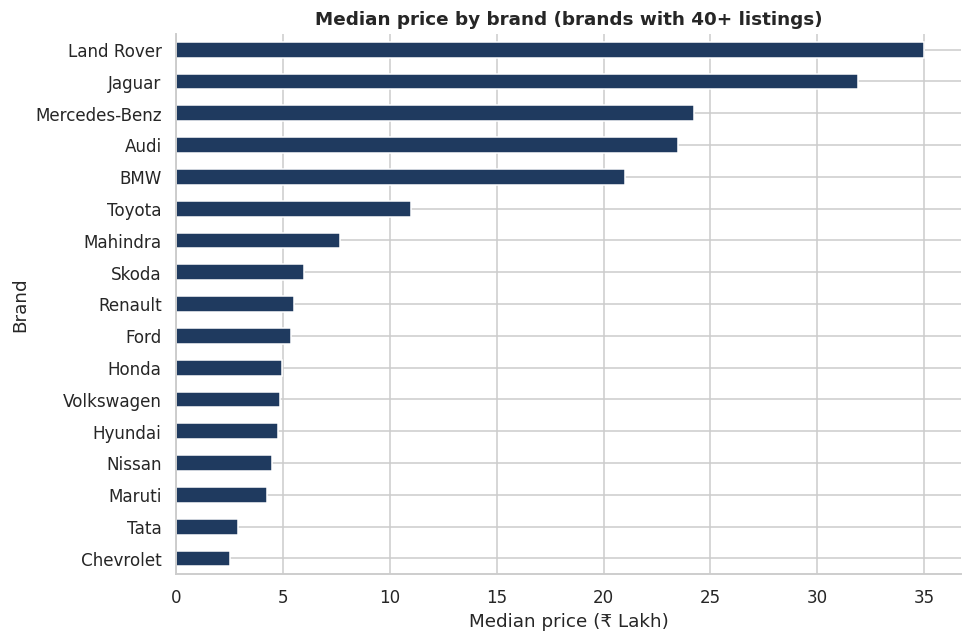

In [8]:
top = df['Brand'].value_counts().loc[lambda s: s >= 40].index
bp = df[df['Brand'].isin(top)].groupby('Brand')['Price'].median().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
bp.plot.barh(color=NAVY, ax=ax); ax.set_title('Median price by brand (brands with 40+ listings)'); ax.set_xlabel('Median price (₹ Lakh)')
plt.tight_layout(); plt.savefig('figures/eda_brand.png', dpi=160, bbox_inches='tight'); plt.show()

**Insight.** Automatic cars, diesel cars, first-owner cars and premium brands (Land Rover, Mercedes-Benz, BMW, Audi, Jaguar) command higher prices; location effects are smaller but visible (e.g., Coimbatore and Bangalore vs Kolkata/Jaipur).

### 3.5 Correlation structure

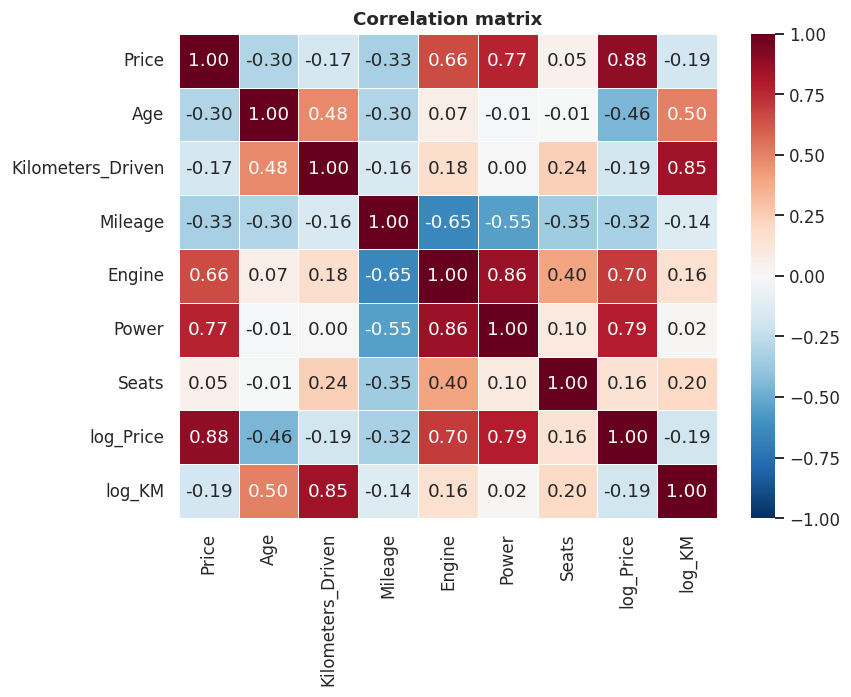

,Price
Power,0.772
Engine,0.656
Seats,0.054
Kilometers_Driven,-0.175
log_KM,-0.186
Age,-0.300
Mileage,-0.334


In [9]:
num = df[['Price', 'Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']].copy()
num['log_Price'] = np.log1p(num['Price']); num['log_KM'] = np.log1p(num['Kilometers_Driven'])
corr = num.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=.5, ax=ax)
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.savefig('figures/eda_corr.png', dpi=160, bbox_inches='tight'); plt.show()
corr['Price'].drop(['Price', 'log_Price']).sort_values(ascending=False).round(3)

**Insight.** Power and engine size are the strongest positive correlates of price, age the strongest negative; `Power` and `Engine` are highly collinear (~0.86), which motivates **Ridge** regularisation in the regression experiments.

### 3.6 Missing values after cleaning

In [10]:
m = df.isna().sum(); print(m[m > 0].to_string())
print('\nCleaned shape:', df.shape)

Mileage    42
Engine     36
Power      36
Seats      38

Cleaned shape: (5843, 12)


In [11]:
# Shared model feature definitions
NUM_FEATURES = ['Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
CAT_FEATURES = ['Brand', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split

def make_preprocessor():
    # log-transform the heavily skewed odometer, then impute (median) and standardise
    num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                         ('scale', StandardScaler())])
    cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, NUM_FEATURES), ('cat', cat_pipe, CAT_FEATURES)])

X = df[NUM_FEATURES + CAT_FEATURES].copy()
X['Kilometers_Driven'] = np.log1p(X['Kilometers_Driven'])   # tame the long right tail
print('Feature matrix:', X.shape)

Feature matrix: (5843, 11)


## 4. Classification implementation
**Goal:** classify a used car into a **price band** — *Low*, *Mid*, *High* — using the tertiles (33rd / 67th percentiles) of the **training** prices, so the classes are balanced.

| Model | Syllabus link (Unit-2) |
|---|---|
| **Logistic Regression** | Probabilistic discriminative model (multinomial, softmax) |
| **SVM (RBF kernel)** | Kernel functions & kernel trick, SVMs |

Hyper-parameters are tuned with 5-fold cross-validated grid search on the training set only.

Price-band thresholds from training data: Low < 4.25 Lakh <= Mid < 7.95 Lakh <= High
Train class counts: [1517 1598 1559] | Test class counts: [395 383 391]


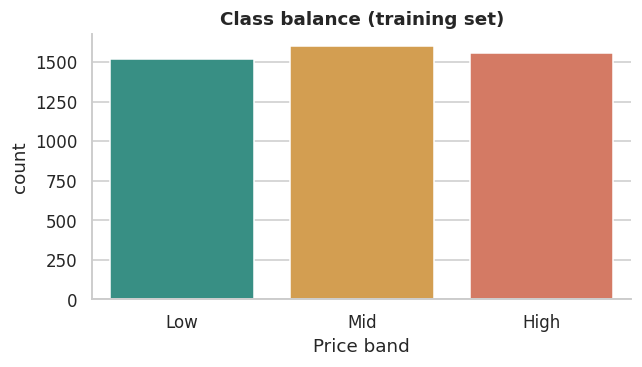

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

X_tr, X_te, p_tr, p_te = train_test_split(X, df['Price'].values, test_size=0.2, random_state=RANDOM_STATE)
q1, q2 = np.quantile(p_tr, [1/3, 2/3])
print(f'Price-band thresholds from training data: Low < {q1:.2f} Lakh <= Mid < {q2:.2f} Lakh <= High')
CLASSES = ['Low', 'Mid', 'High']
to_band = lambda p: np.where(p < q1, 0, np.where(p < q2, 1, 2))
y_tr, y_te = to_band(p_tr), to_band(p_te)
print('Train class counts:', np.bincount(y_tr), '| Test class counts:', np.bincount(y_te))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(x=pd.Series(y_tr).map(dict(enumerate(CLASSES))), order=CLASSES, palette=[TEAL, AMBER, CORAL], ax=ax)
ax.set_title('Class balance (training set)'); ax.set_xlabel('Price band'); plt.tight_layout()
plt.savefig('figures/cls_balance.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.1 Model A — Logistic Regression

In [13]:
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
lr_gs = GridSearchCV(Pipeline([('prep', make_preprocessor()), ('model', LogisticRegression(max_iter=3000))]),
                     {'model__C': [0.01, 0.1, 1, 10, 100]}, cv=skf, scoring='accuracy', n_jobs=-1).fit(X_tr, y_tr)
print('Best params:', lr_gs.best_params_, '| CV accuracy: %.4f' % lr_gs.best_score_)
lr = lr_gs.best_estimator_

Best params: {'model__C': 100} | CV accuracy: 0.8609


### 4.2 Model B — Support Vector Machine (RBF kernel)

In [14]:
svm_gs = GridSearchCV(Pipeline([('prep', make_preprocessor()), ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))]),
                      {'model__C': [1, 10, 100], 'model__gamma': ['scale', 0.003, 0.01]}, cv=skf, scoring='accuracy', n_jobs=-1).fit(X_tr, y_tr)
print('Best params:', svm_gs.best_params_, '| CV accuracy: %.4f' % svm_gs.best_score_)
svm = svm_gs.best_estimator_

Best params: {'model__C': 10, 'model__gamma': 'scale'} | CV accuracy: 0.8738


### 4.3 Evaluation

In [15]:
def evaluate(name, model, cv_acc):
    pred = model.predict(X_te); proba = model.predict_proba(X_te)
    p, r, f, _ = precision_recall_fscore_support(y_te, pred, average='macro')
    return {'Model': name, 'Accuracy': accuracy_score(y_te, pred), 'Precision (macro)': p, 'Recall (macro)': r, 'F1 (macro)': f,
            'ROC-AUC (OvR)': roc_auc_score(y_te, proba, multi_class='ovr'), 'CV accuracy': cv_acc}, pred, proba

r_lr, pred_lr, proba_lr = evaluate('Logistic Regression', lr, lr_gs.best_score_)
r_svm, pred_svm, proba_svm = evaluate('SVM (RBF kernel)', svm, svm_gs.best_score_)
res = pd.DataFrame([r_lr, r_svm]).set_index('Model'); display(res.round(4))
for n, p in [('Logistic Regression', pred_lr), ('SVM (RBF kernel)', pred_svm)]:
    print('\n' + n); print(classification_report(y_te, p, target_names=CLASSES, digits=3))

,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR),CV accuracy
Model,,,,,,
Logistic Regression,0.8358,0.8403,0.8356,0.8369,0.9551,0.8609
SVM (RBF kernel),0.8537,0.8567,0.8535,0.8543,0.9616,0.8738



Logistic Regression
              precision    recall  f1-score   support

         Low      0.875     0.818     0.846       395
         Mid      0.727     0.802     0.763       383
        High      0.918     0.887     0.902       391

    accuracy                          0.836      1169
   macro avg      0.840     0.836     0.837      1169
weighted avg      0.841     0.836     0.837      1169


SVM (RBF kernel)
              precision    recall  f1-score   support

         Low      0.908     0.846     0.875       395
         Mid      0.760     0.820     0.789       383
        High      0.902     0.895     0.899       391

    accuracy                          0.854      1169
   macro avg      0.857     0.854     0.854      1169
weighted avg      0.857     0.854     0.855      1169



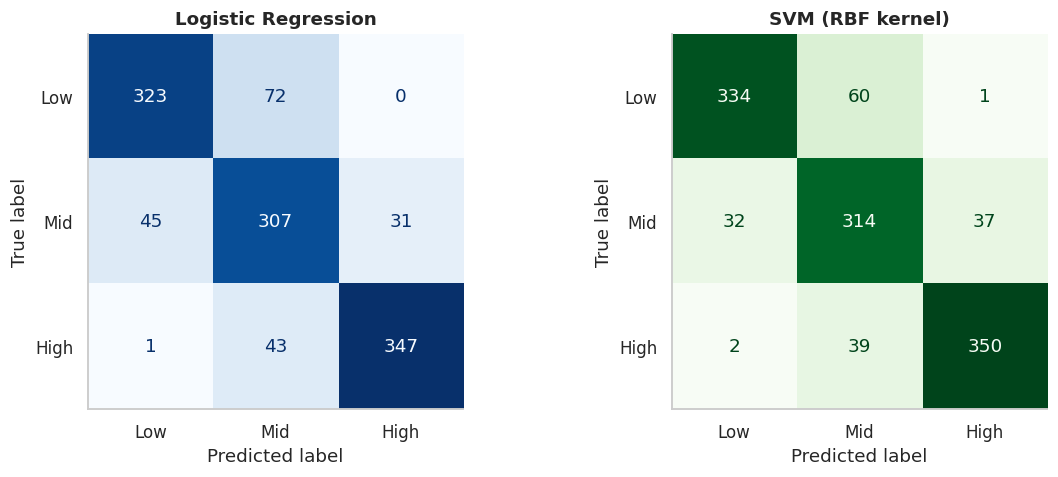

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, nm, p, cm_ in zip(ax, ['Logistic Regression', 'SVM (RBF kernel)'], [pred_lr, pred_svm], ['Blues', 'Greens']):
    ConfusionMatrixDisplay(confusion_matrix(y_te, p), display_labels=CLASSES).plot(ax=a, cmap=cm_, colorbar=False); a.set_title(nm); a.grid(False)
plt.tight_layout(); plt.savefig('figures/cls_confusion.png', dpi=160, bbox_inches='tight'); plt.show()

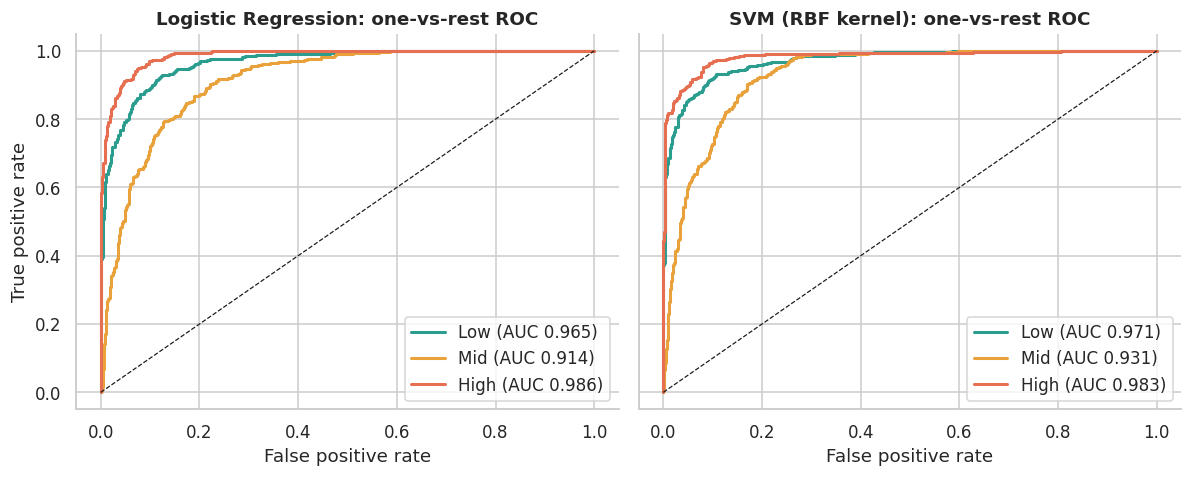

In [17]:
Yb = label_binarize(y_te, classes=[0, 1, 2])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for a, nm, pr in zip(ax, ['Logistic Regression', 'SVM (RBF kernel)'], [proba_lr, proba_svm]):
    for k, (cl, c) in enumerate(zip(CLASSES, [TEAL, AMBER, CORAL])):
        fpr, tpr, _ = roc_curve(Yb[:, k], pr[:, k]); a.plot(fpr, tpr, color=c, lw=2, label=f'{cl} (AUC {roc_auc_score(Yb[:, k], pr[:, k]):.3f})')
    a.plot([0, 1], [0, 1], 'k--', lw=.8); a.set_title(f'{nm}: one-vs-rest ROC'); a.set_xlabel('False positive rate'); a.legend(loc='lower right')
ax[0].set_ylabel('True positive rate'); plt.tight_layout(); plt.savefig('figures/cls_roc.png', dpi=160, bbox_inches='tight'); plt.show()

In [18]:
cms = {n: confusion_matrix(y_te, p).tolist() for n, p in [('Logistic Regression', pred_lr), ('SVM (RBF kernel)', pred_svm)]}
per_class = {n: {c: dict(zip(['precision', 'recall', 'f1'], [round(float(v[i]), 4) for v in precision_recall_fscore_support(y_te, p)[:3]])) for i, c in enumerate(CLASSES)}
             for n, p in [('Logistic Regression', pred_lr), ('SVM (RBF kernel)', pred_svm)]}
out = {'task': 'classification', 'n_train': int(len(X_tr)), 'n_test': int(len(X_te)), 'thresholds': [float(q1), float(q2)],
       'best_params': {'logreg': lr_gs.best_params_, 'svm': {k: (v if isinstance(v, str) else float(v)) for k, v in svm_gs.best_params_.items()}},
       'results': res.reset_index().to_dict(orient='records'), 'confusion': cms, 'per_class': per_class}
json.dump(out, open('results_classification.json', 'w'), indent=2, default=float)
print('Saved results_classification.json')

Saved results_classification.json


## 5. Interpretation
* Both classifiers separate *Low* and *High* cars well; most errors occur between **adjacent bands** (Low↔Mid, Mid↔High), which is expected because price is continuous and band boundaries are arbitrary cut-offs.
* The **RBF-kernel SVM** can bend its decision boundary (kernel trick), while Logistic Regression is limited to linear boundaries in the engineered feature space — compare the two rows of the results table.
* ROC curves show the extreme classes are easiest to detect; the *Mid* band is hardest.